#  Análise Exploratória de Dados (EDA): Goodreads Dataset

In [2]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))


# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nossos módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Carregando Dados

In [3]:
caminho = '../data/interim/books/goodreads_books_cleaned.parquet'
df_books = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (10965, 12)


---
## Análise Univariada

In [4]:
df_colunas = pd.DataFrame({
    "coluna": df_books.columns,
    "dtype_pandas": df_books.dtypes.values,
    "tipo_real": [
        df_books[col].map(type)[0].__name__
        if not df_books[col].dropna().empty else None
        for col in df_books.columns
    ]
})

display(tb.estilizar_tabela(
    df=df_colunas,
    caption="Colunas do dataframe"
))

,coluna,dtype_pandas,tipo_real
0,book_id,int64,int
1,title,object,str
2,Author,object,str
3,average_rating,float64,float
4,isbn,object,str
5,language_code,object,str
6,num_pages,int64,int
7,ratings_count,int64,int
8,text_reviews_count,int64,int
9,publication_date,datetime64[ns],Timestamp


### Colunas Numéricas

In [5]:
# Análisado Colunas Numéricas Individualmente
resumo_cols_numericas = mt.numeric_summary(df_books)
display(
    tb.estilizar_tabela(
        resumo_cols_numericas,
        caption="Relatorio colunas numéricas"
    ).format("{:,.2f}")
)

,mean,median,std,min,max,iqr,skew,kurtosis,outlier_count,outlier_%
column,,,,,,,,,,
book_id,"21,283.36","20,235.00","13,080.32",1.00,"45,641.00","21,796.00",0.15,-1.14,0.00,0.00
ratings_count,"18,201.30",784.00,"113,286.10",1.00,"4,597,666.00","5,035.00",17.57,436.11,"1,686.00",15.38
text_reviews_count,549.85,49.00,"2,594.29",0.00,"94,265.00",235.00,16.07,391.20,"1,591.00",14.51
num_pages,338.04,301.00,240.89,0.00,"6,576.00",220.00,4.33,63.48,557.00,5.08
average_rating,3.94,3.96,0.29,2.00,5.00,0.35,-0.57,1.95,233.00,2.12


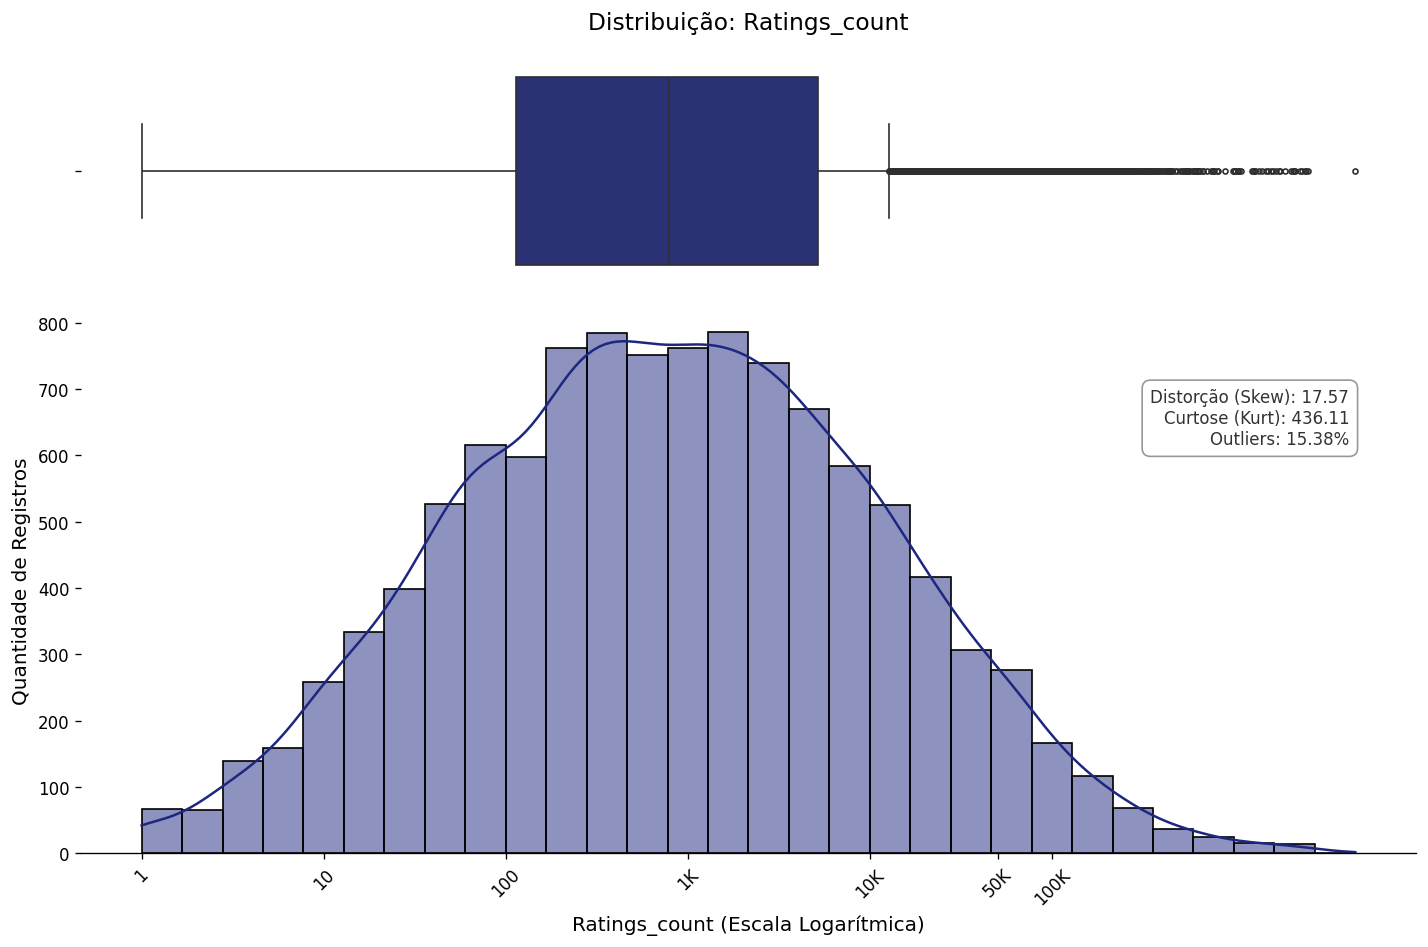

In [6]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='ratings_count', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='contagem'
)

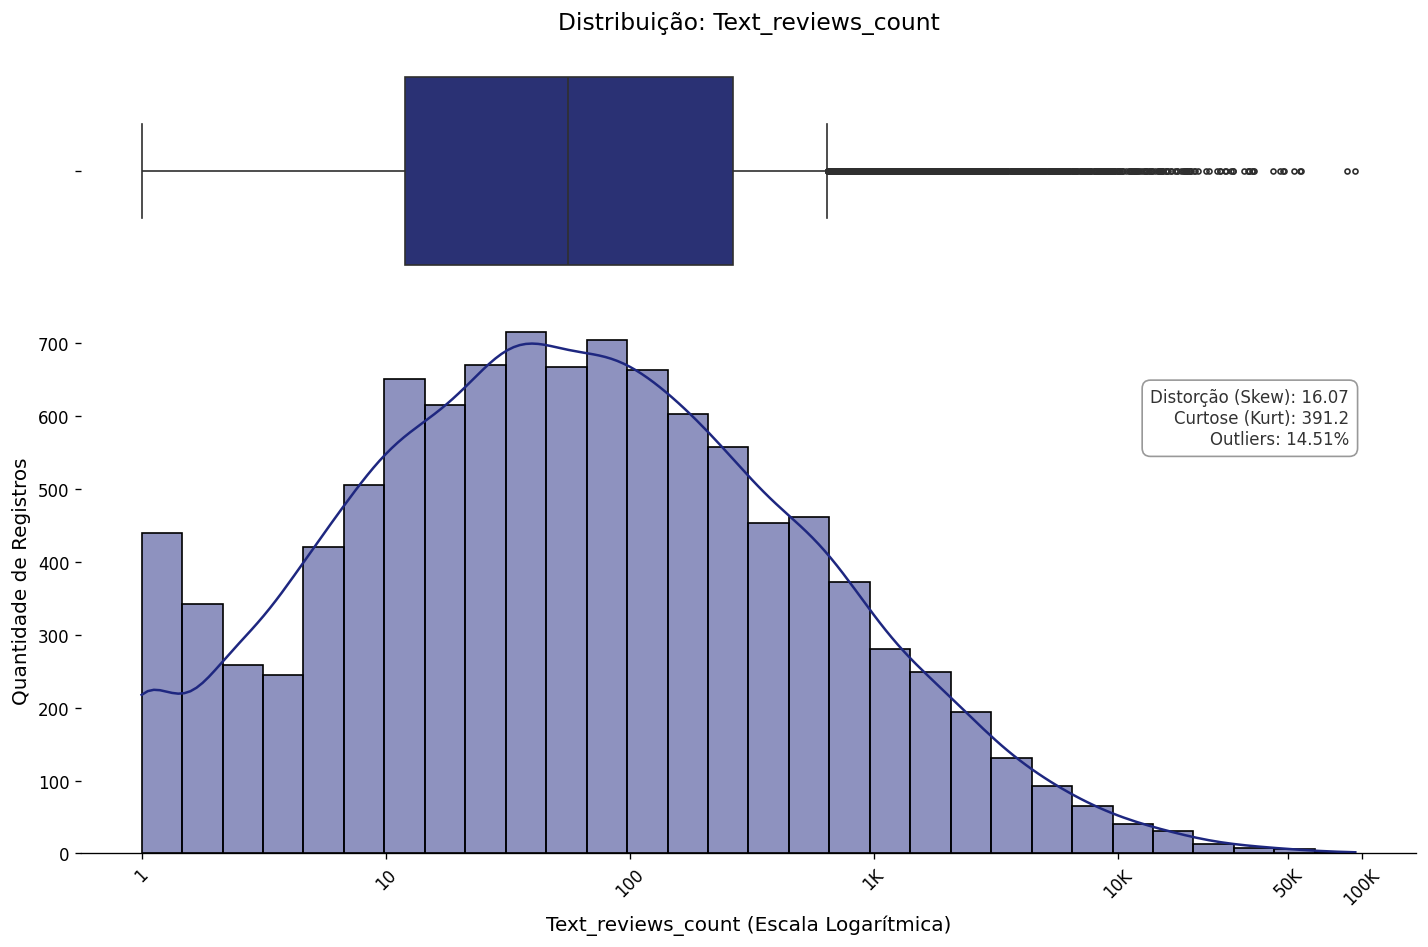

In [7]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='text_reviews_count', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='contagem'
)

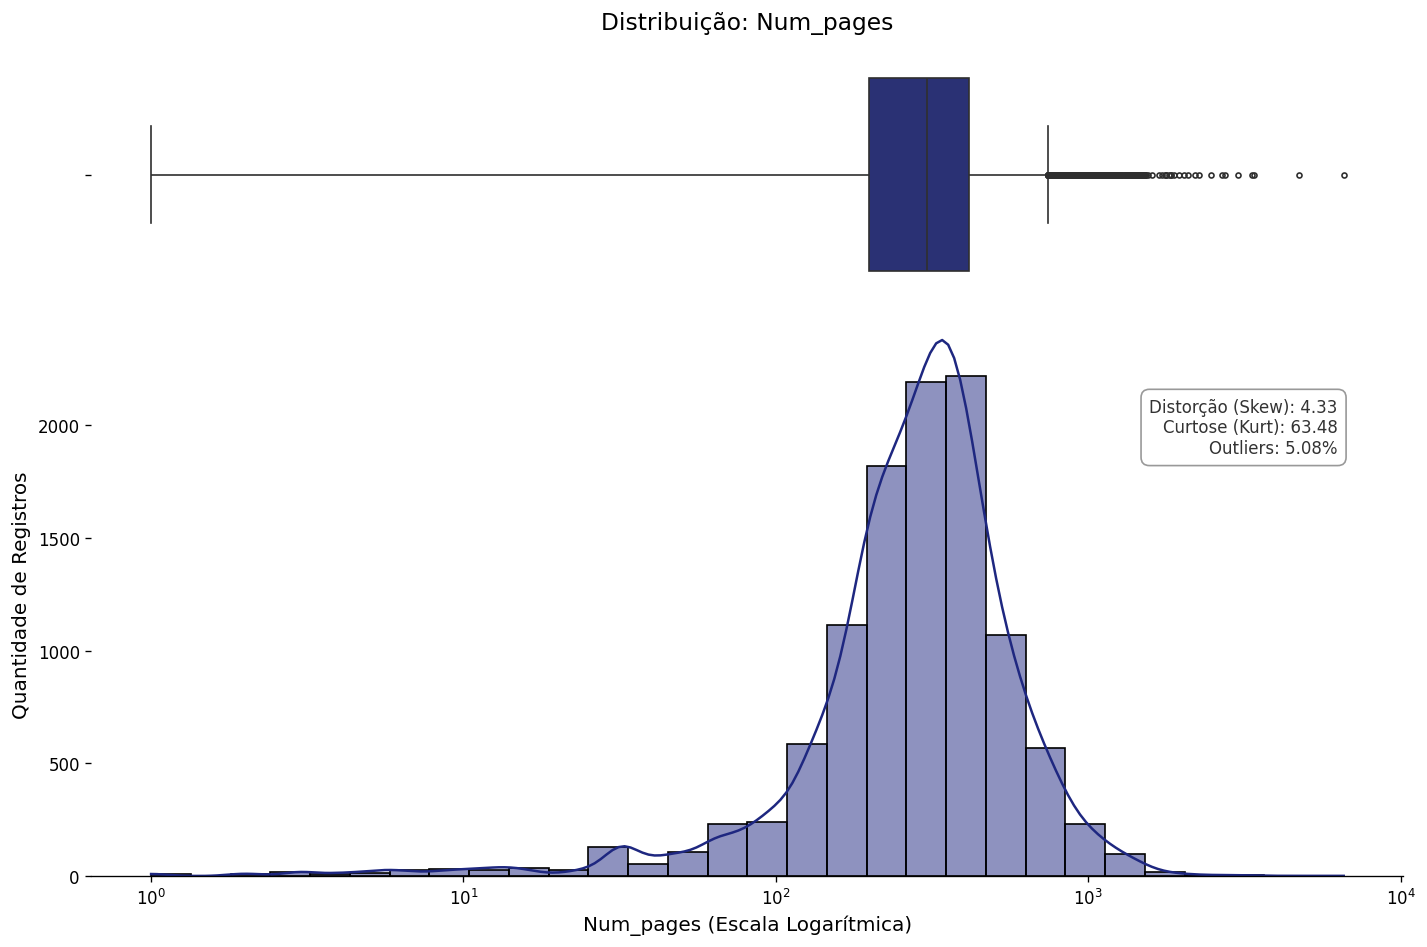

In [8]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='num_pages', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True
)

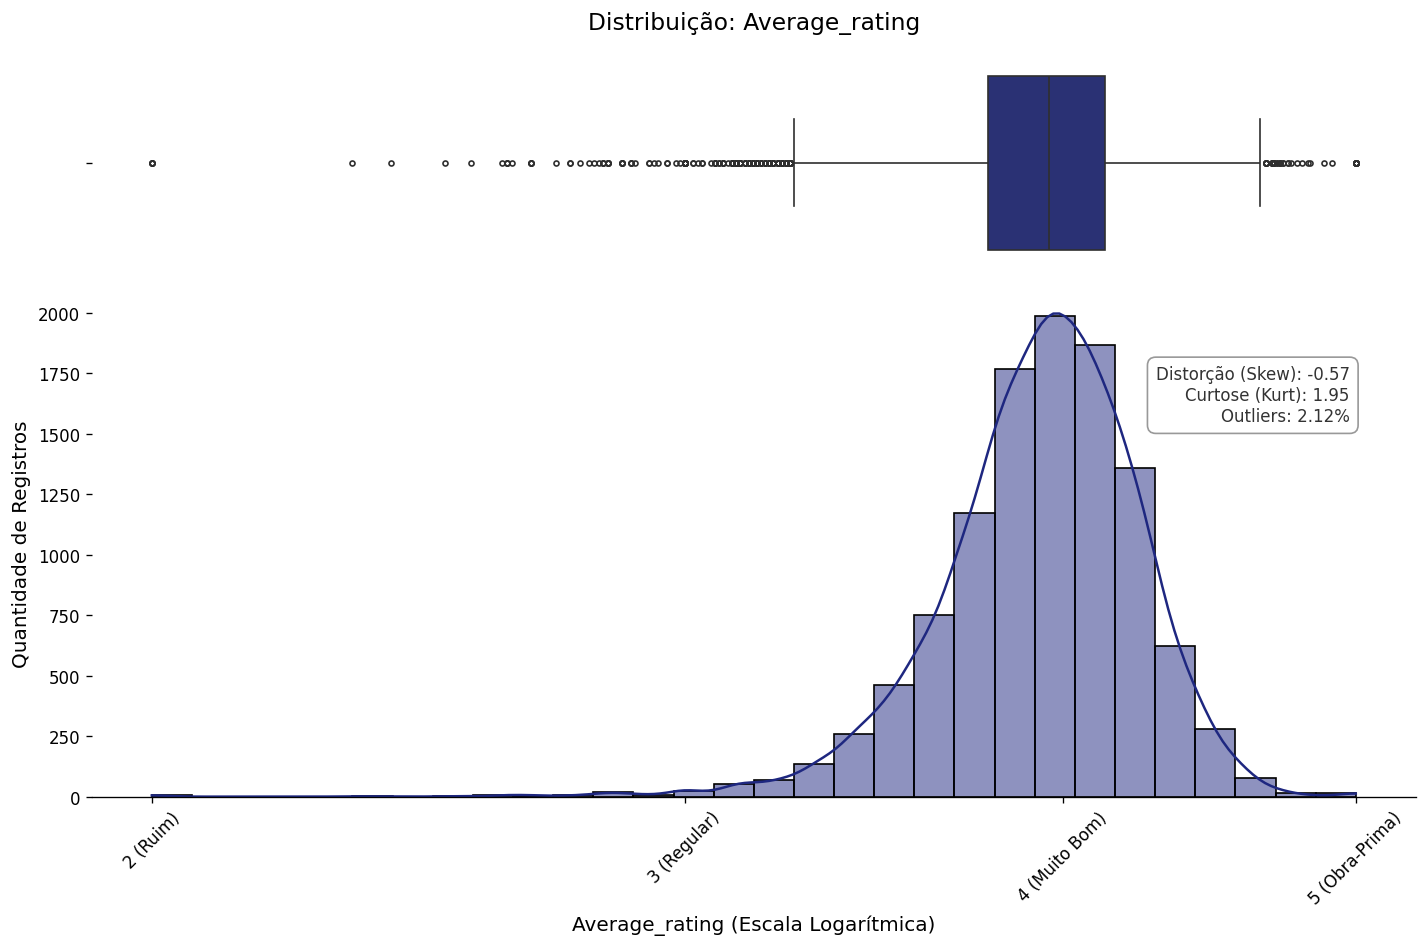

In [9]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='average_rating', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='nota_5'
)

### Colunas Categoricas

In [10]:
# Análisado Colunas Categorical Individualmente
resumo_cols_categoricas = mt.categorical_summary(df_books)
display(
    tb.estilizar_relatorio_categorias(
        resumo_cols_categoricas,
        caption="Relatorio colunas categoricas"
    )
)

,total_valid_rows,unique_categories,entropy_norm,top_values_count,top_values_pct_%
column,,,,,
isbn,10965,10965,1.000000,• 0439785960 (1)• 0439358078 (1)• 0439554896 (1)• 043965548X (1)• 0439682584 (1)• 0976540606 (1)• 0439827604 (1)• 0517226952 (1)• 0345453743 (1)• 1400052920 (1),• 0439785960 (0.0%)• 0439358078 (0.0%)• 0439554896 (0.0%)• 043965548X (0.0%)• 0439682584 (0.0%)• 0976540606 (0.0%)• 0439827604 (0.0%)• 0517226952 (0.0%)• 0345453743 (0.0%)• 1400052920 (0.0%)
title,10965,10196,0.995100,• The Iliad (9)• The Brothers Karamazov (9)• Anna Karenina (8)• The Odyssey (8)• Gulliver's Travels (8)• 'Salem's Lot (8)• The Picture of Dorian Gray (7)• A Midsummer Night's Dream (7)• Collected Stories (6)• The Great Gatsby (6),• The Iliad (0.1%)• The Brothers Karamazov (0.1%)• Anna Karenina (0.1%)• The Odyssey (0.1%)• Gulliver's Travels (0.1%)• 'Salem's Lot (0.1%)• The Picture of Dorian Gray (0.1%)• A Midsummer Night's Dream (0.1%)• Collected Stories (0.1%)• The Great Gatsby (0.1%)
Author,10965,6528,0.954100,• Stephen King (40)• P.G. Wodehouse (40)• Rumiko Takahashi (38)• Orson Scott Card (35)• Agatha Christie (33)• Piers Anthony (30)• Mercedes Lackey (29)• Sandra Brown (29)• Dick Francis (28)• Margaret Weis/Tracy Hickman (23),• Stephen King (0.4%)• P.G. Wodehouse (0.4%)• Rumiko Takahashi (0.3%)• Orson Scott Card (0.3%)• Agatha Christie (0.3%)• Piers Anthony (0.3%)• Mercedes Lackey (0.3%)• Sandra Brown (0.3%)• Dick Francis (0.3%)• Margaret Weis/Tracy Hickman (0.2%)
publisher,10965,2227,0.844700,• Vintage (318)• Penguin Books (261)• Penguin Classics (184)• Mariner Books (149)• Ballantine Books (144)• HarperCollins (112)• Harper Perennial (112)• Pocket Books (111)• Bantam (110)• VIZ Media LLC (88),• Vintage (2.9%)• Penguin Books (2.4%)• Penguin Classics (1.7%)• Mariner Books (1.4%)• Ballantine Books (1.3%)• HarperCollins (1.0%)• Harper Perennial (1.0%)• Pocket Books (1.0%)• Bantam (1.0%)• VIZ Media LLC (0.8%)
genres,10965,852,0.745000,"• Fiction (6852)• Classics (3321)• Nonfiction (3073)• Literature (2840)• Fantasy (2541)• Novels (2522)• Historical,Historical Fiction (1783)• Audiobook (1634)• Mystery (1596)• History (1583)","• Fiction (62.5%)• Classics (30.3%)• Nonfiction (28.0%)• Literature (25.9%)• Fantasy (23.2%)• Novels (23.0%)• Historical,Historical Fiction (16.3%)• Audiobook (14.9%)• Mystery (14.6%)• History (14.4%)"
language_code,10965,25,0.238200,• eng (8778)• en-US (1403)• en-GB (214)• spa (210)• fre (139)• ger (95)• jpn (45)• mul (19)• zho (14)• por (10),• eng (80.1%)• en-US (12.8%)• en-GB (2.0%)• spa (1.9%)• fre (1.3%)• ger (0.9%)• jpn (0.4%)• mul (0.2%)• zho (0.1%)• por (0.1%)


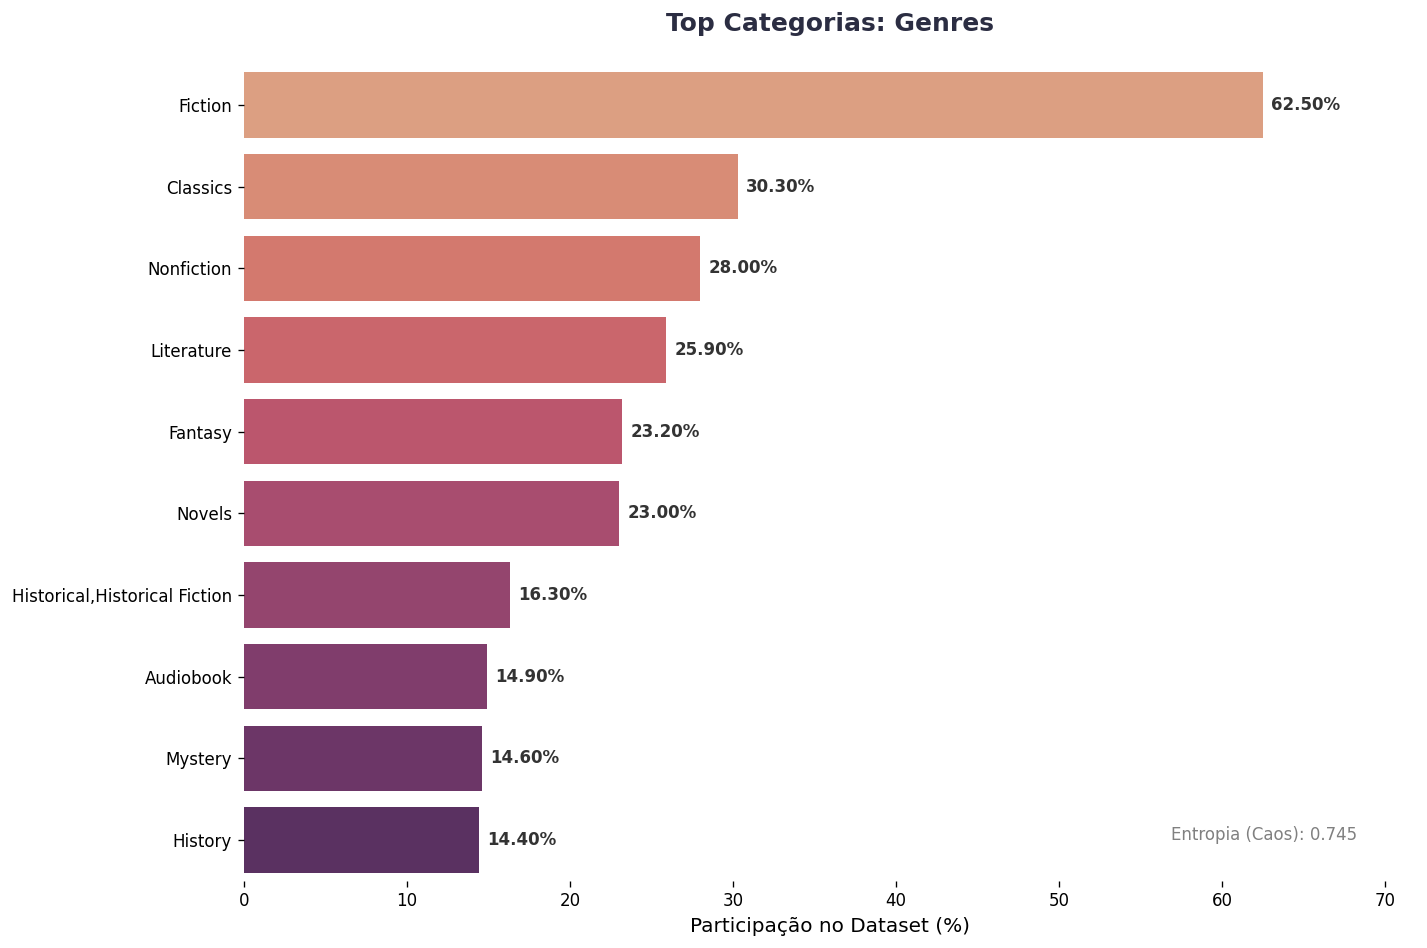

In [11]:
graf.grafico_top_categorias(df_books, 'genres', resumo_cols_categoricas)

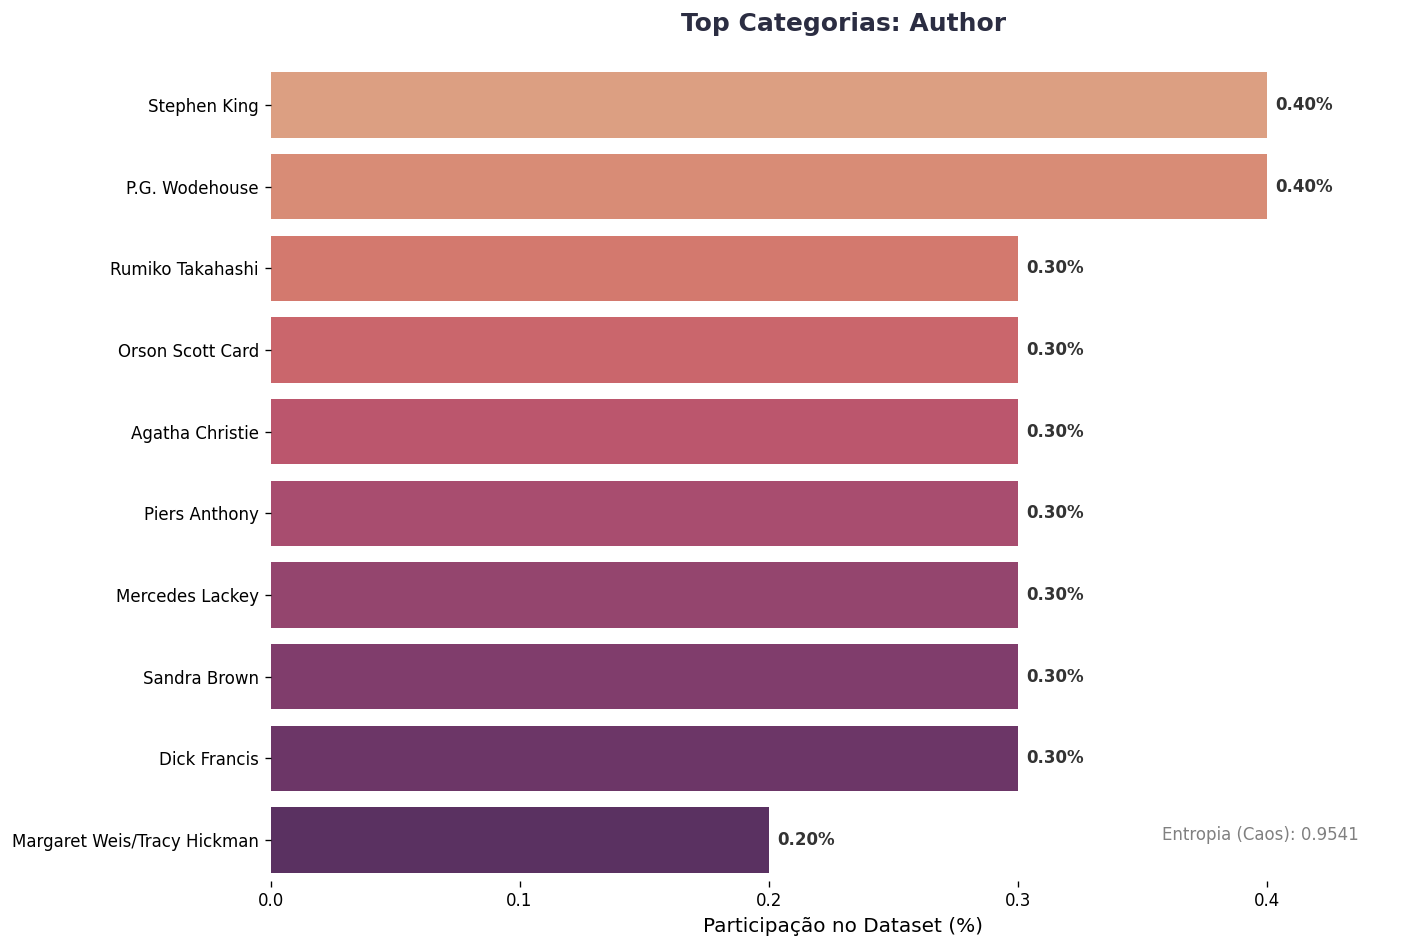

In [12]:
graf.grafico_top_categorias(df_books, 'Author', resumo_cols_categoricas)

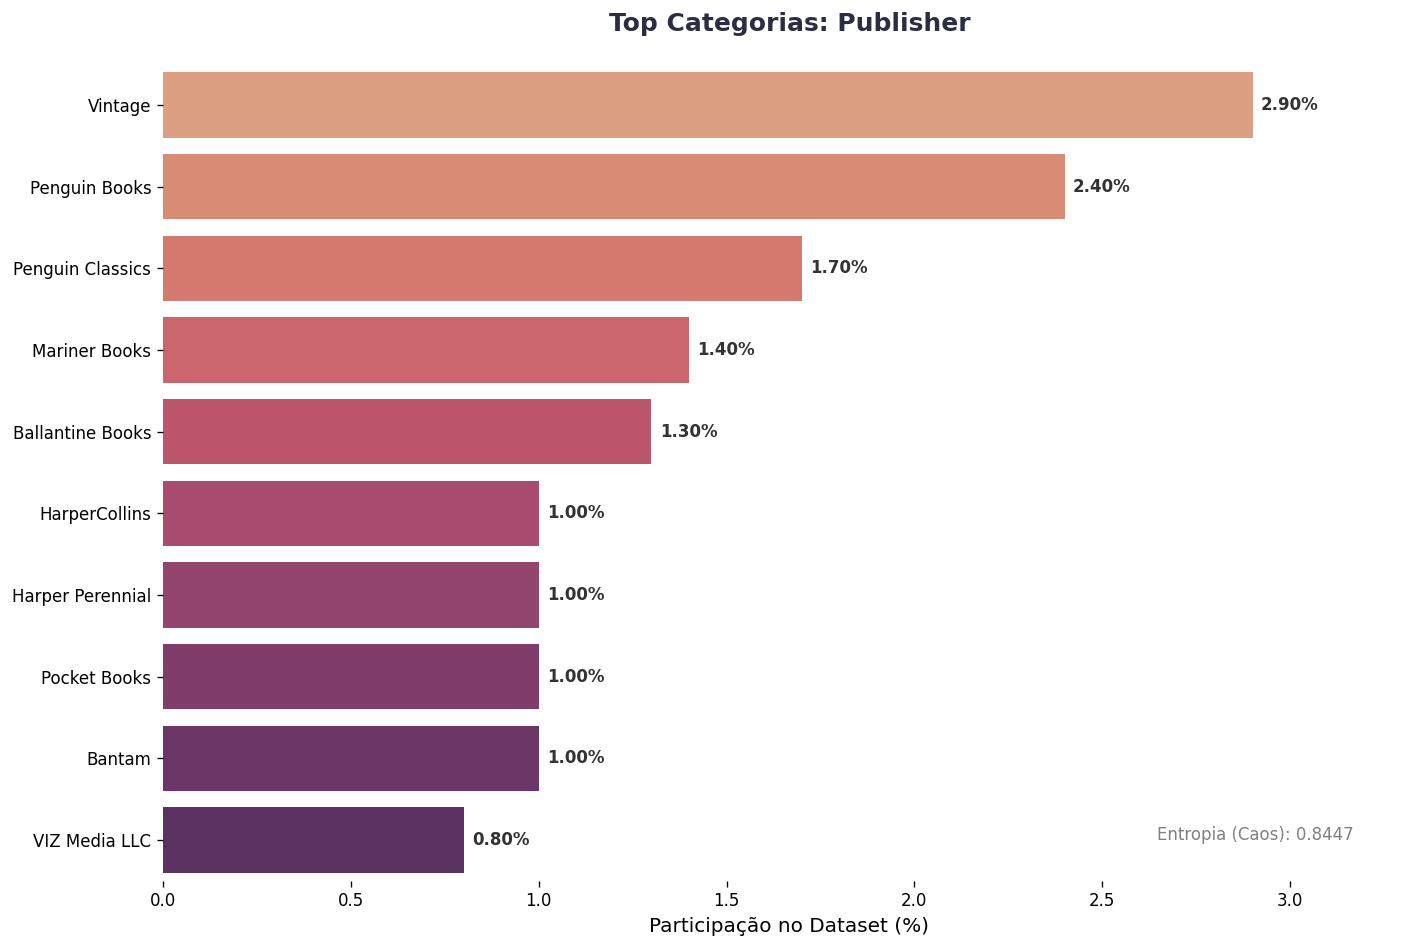

In [13]:
graf.grafico_top_categorias(df_books, 'publisher', resumo_cols_categoricas)

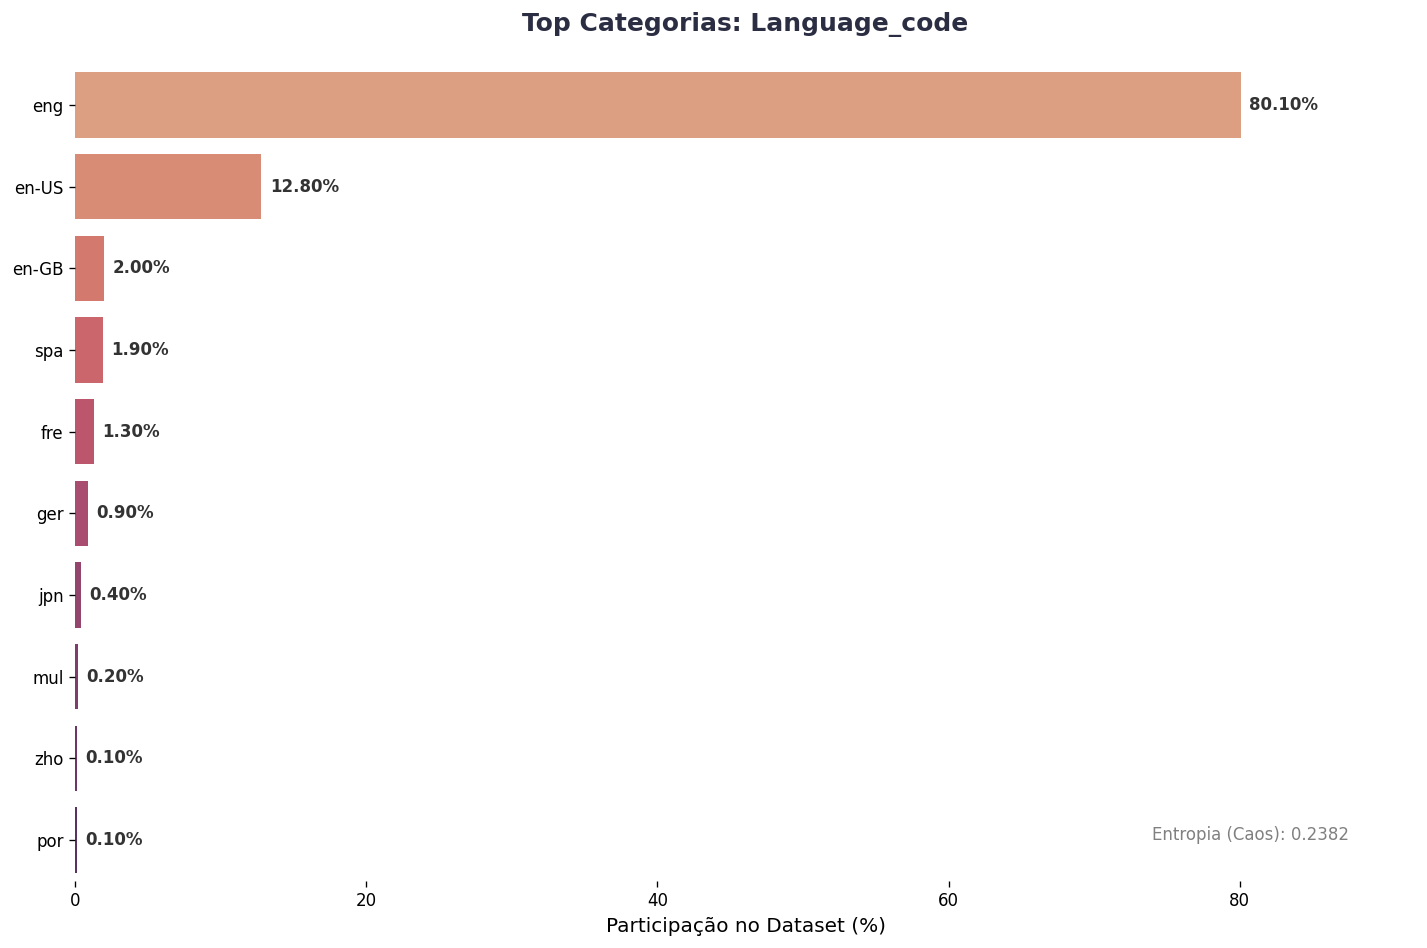

In [14]:
graf.grafico_top_categorias(df_books, 'language_code', resumo_cols_categoricas)

# Conclusões da Análise Univariada & Próximos Passos

## 1. Variáveis Numéricas

* **`ratings_count` e `text_reviews_count` (Engajamento):** Assimetria extrema (Cauda Longa). A maioria dos livros tem poucos votos (mediana de 784), enquanto uma minoria de best-sellers concentra milhões de avaliações. Escala logarítmica indispensável para visualização.
* **`num_pages` (Tamanho):** Concentração no padrão de **300 a 338 páginas**. Presença de volumes extremos (até 6.576 páginas) gerando 5.08% de outliers (possíveis boxes/coleções).
* **`average_rating` (Notas):** Distribuição Normal perfeitamente equilibrada, concentrada entre **3.5 e 4.2** (média 3.94). O público leitor é generoso; notas menores que 2.0 ou perfeitas (5.0) são raras.

## 2. Variáveis Categorizadas

* **`language_code` (Idioma):** Baixíssima entropia (0.23). Domínio absoluto do inglês (> 94.9%). O português representa apenas 0.1%. Será útil para segmentar o Dashboard por mercado.
* **`genres` (Gêneros):** Alta entropia (0.74). Mercado bem distribuído. *Fiction* (62.5%) e *Classics* (30.3%) lideram, mas Fantasia, Mistério e Ficção Histórica têm fatias relevantes.
* **`title` e `Author`:** Alta fragmentação (entropia > 0.95). Stephen King e P.G. Wodehouse lideram com apenas 0.4% do catálogo cada.

## 3. Qualidade dos Dados (Auditoria)

* **`isbn`:** Preservado como identificador padrão para futuros cruzamentos externos.
* **Duplicados:** A coluna `title` possui reedições e formatos diferentes (Paperback/Hardcover) do mesmo livro, gerando repetições legítimas de clássicos.
* **Dados Nulos:** Identificados livros com 0 páginas, que serão tratados como `NaN` na etapa de *Data Cleaning*.

---
## Análise Bivariada

### Valores Impossíveis

In [15]:
# Verifica quais valores são menores que zero (< 0)

display(tb.estilizar_tabela(
    df=(df_books.select_dtypes(include='number') < 0)
        .sum()
        .to_frame(name='contagem'
    ),
    caption="Quantidade de valores impossíveis (negativos) por coluna:"
))

,contagem
book_id,0
average_rating,0
num_pages,0
ratings_count,0
text_reviews_count,0


## Numérica VS Numérica

In [16]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_books.select_dtypes(include='number')
        .corr(method='pearson')['ratings_count']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Pearson)'
))

,Correlação
ratings_count,1.000000
text_reviews_count,0.865929
average_rating,0.041397
num_pages,0.033537
book_id,-0.077133


In [17]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_books.select_dtypes(include='number')
        .corr(method='spearman')['ratings_count']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Spearman)'
))

,Correlação
ratings_count,1.000000
text_reviews_count,0.957265
num_pages,0.175292
average_rating,0.082135
book_id,-0.098311


(0.0, 304324.1600000041)

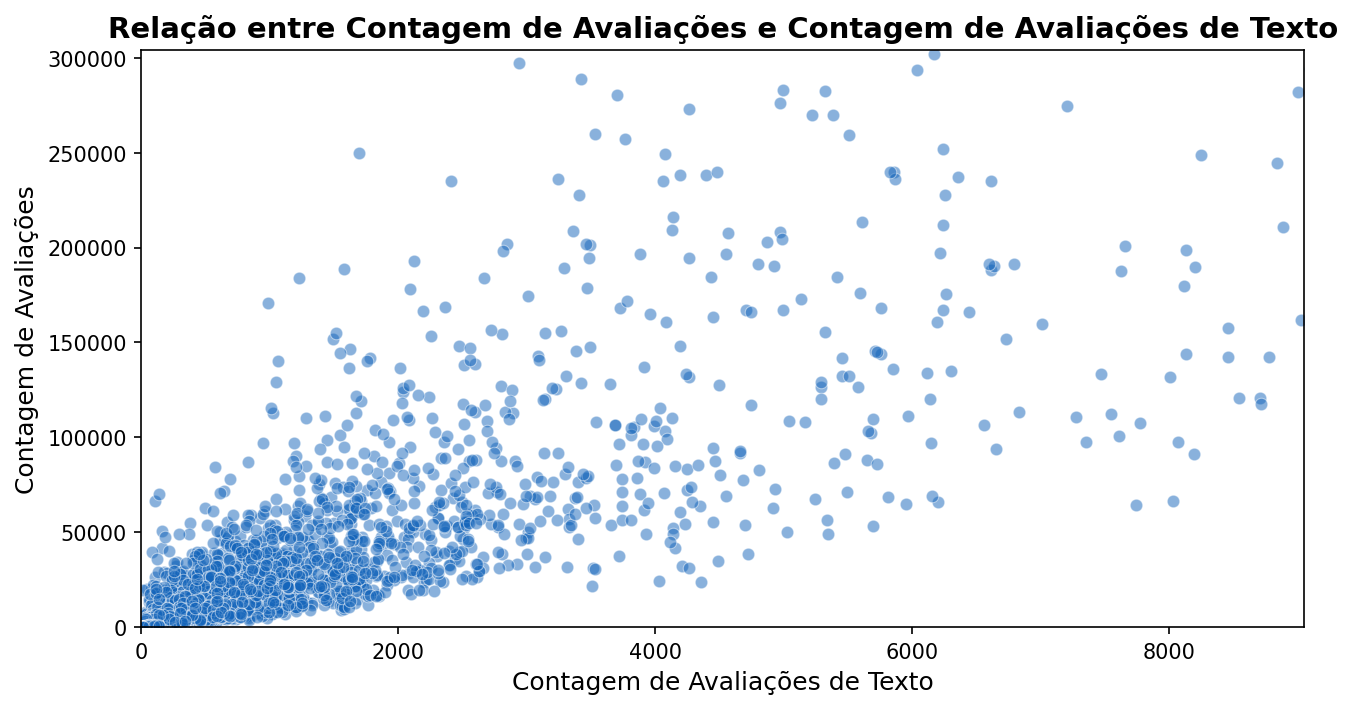

In [18]:
plt.figure(figsize=(10, 5), dpi=150)
sns.scatterplot(
    data=df_books,
    x='text_reviews_count',
    y='ratings_count',
    alpha=0.5,
    color='#1465bb'
)
plt.title('Relação entre Contagem de Avaliações e Contagem de Avaliações de Texto', fontsize=14, fontweight='bold')
plt.xlabel('Contagem de Avaliações de Texto', fontsize=12)
plt.ylabel('Contagem de Avaliações', fontsize=12)

plt.xlim(0, df_books['text_reviews_count'].quantile(0.99))
plt.ylim(0, df_books['ratings_count'].quantile(0.99))

(0.0, 304324.1600000041)

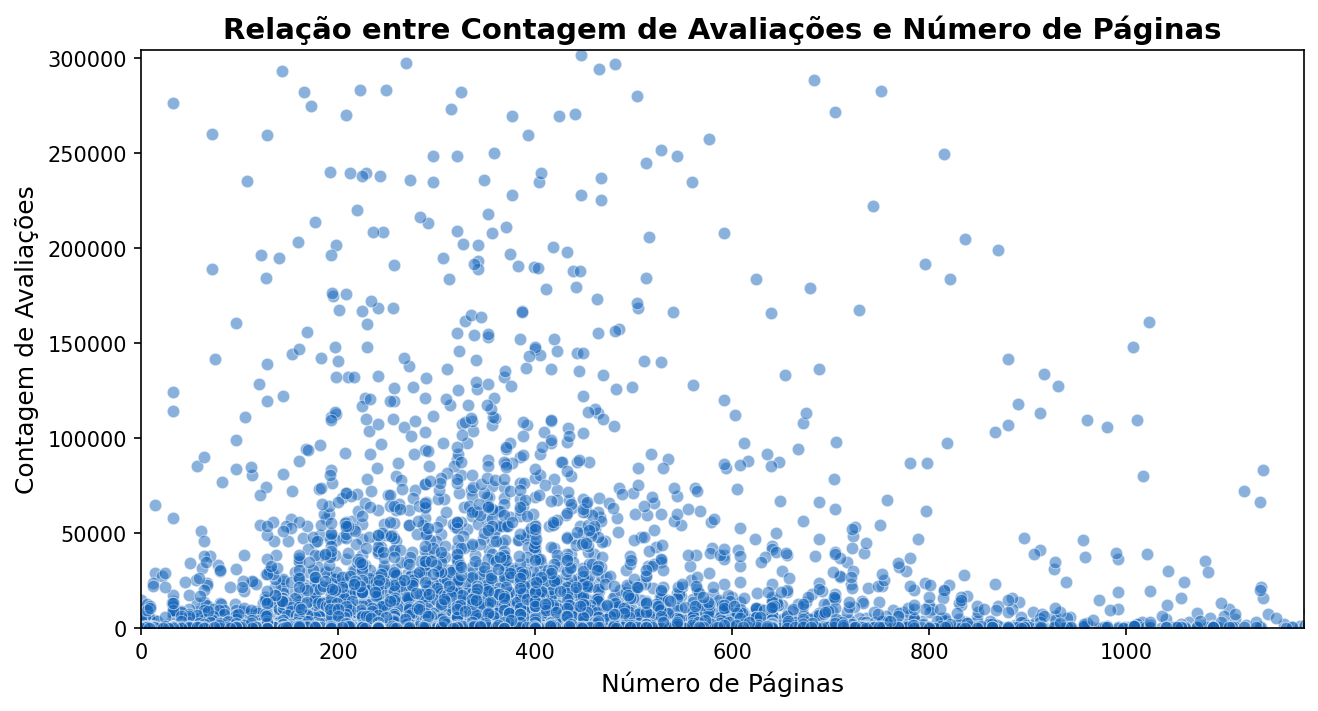

In [19]:
plt.figure(figsize=(10, 5), dpi=150)
sns.scatterplot(
    data=df_books,
    x='num_pages',
    y='ratings_count',
    alpha=0.5,
    color='#1465bb'
)
plt.title('Relação entre Contagem de Avaliações e Número de Páginas', fontsize=14, fontweight='bold')
plt.xlabel('Número de Páginas', fontsize=12)
plt.ylabel('Contagem de Avaliações', fontsize=12)

plt.xlim(0, df_books['num_pages'].quantile(0.99))
plt.ylim(0, df_books['ratings_count'].quantile(0.99))

In [20]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_books
        .select_dtypes(include='number')
        .corr(method='pearson')['average_rating']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Pearson)'
))

,Correlação
average_rating,1.000000
num_pages,0.172264
ratings_count,0.041397
text_reviews_count,0.034173
book_id,-0.038800


In [21]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_books
        .select_dtypes(include='number')
        .corr(method='spearman')['average_rating']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Spearman)'
))

,Correlação
average_rating,1.000000
num_pages,0.112750
ratings_count,0.082135
text_reviews_count,0.026943
book_id,-0.036459


(0.0, 6.0)

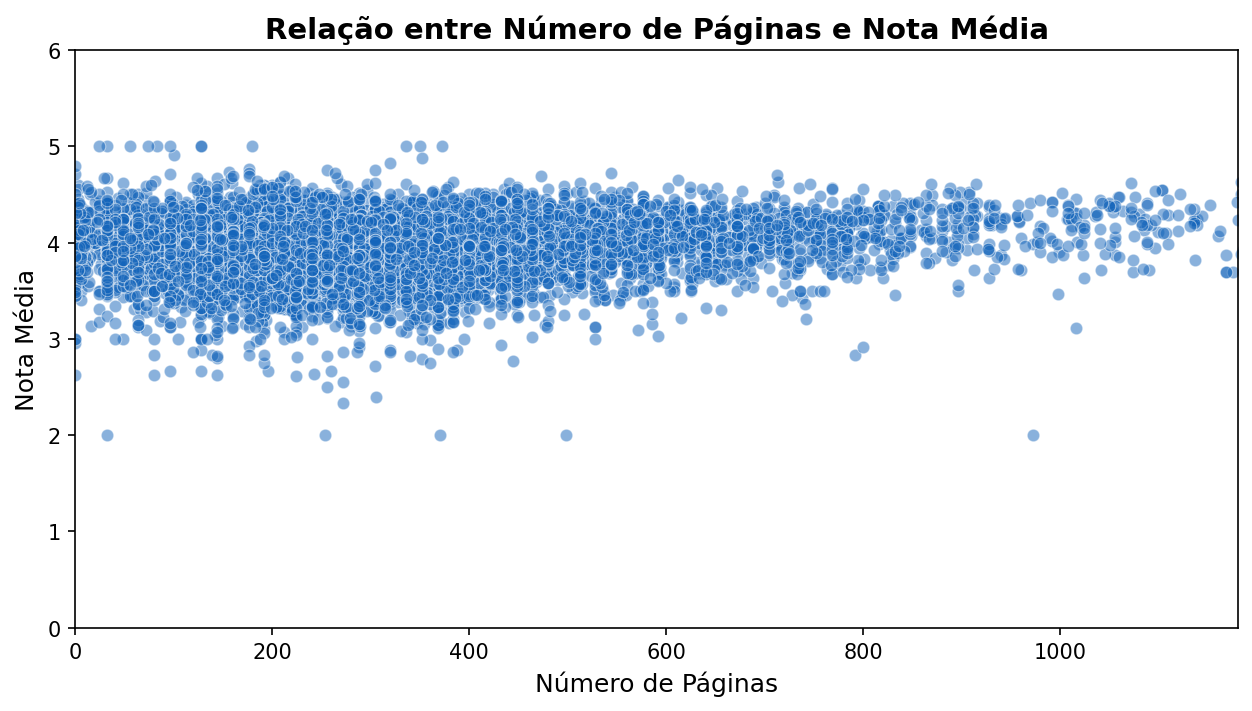

In [22]:
plt.figure(figsize=(10, 5), dpi=150)

sns.scatterplot(
    data=df_books,
    x='num_pages',
    y='average_rating',
    alpha=0.5,
    color='#1465bb'
)

plt.title('Relação entre Número de Páginas e Nota Média', fontsize=14, fontweight='bold')
plt.xlabel('Número de Páginas', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)

plt.xlim(0, df_books['num_pages'].quantile(0.99))
plt.ylim(0, 6)

(0.0, 6.0)

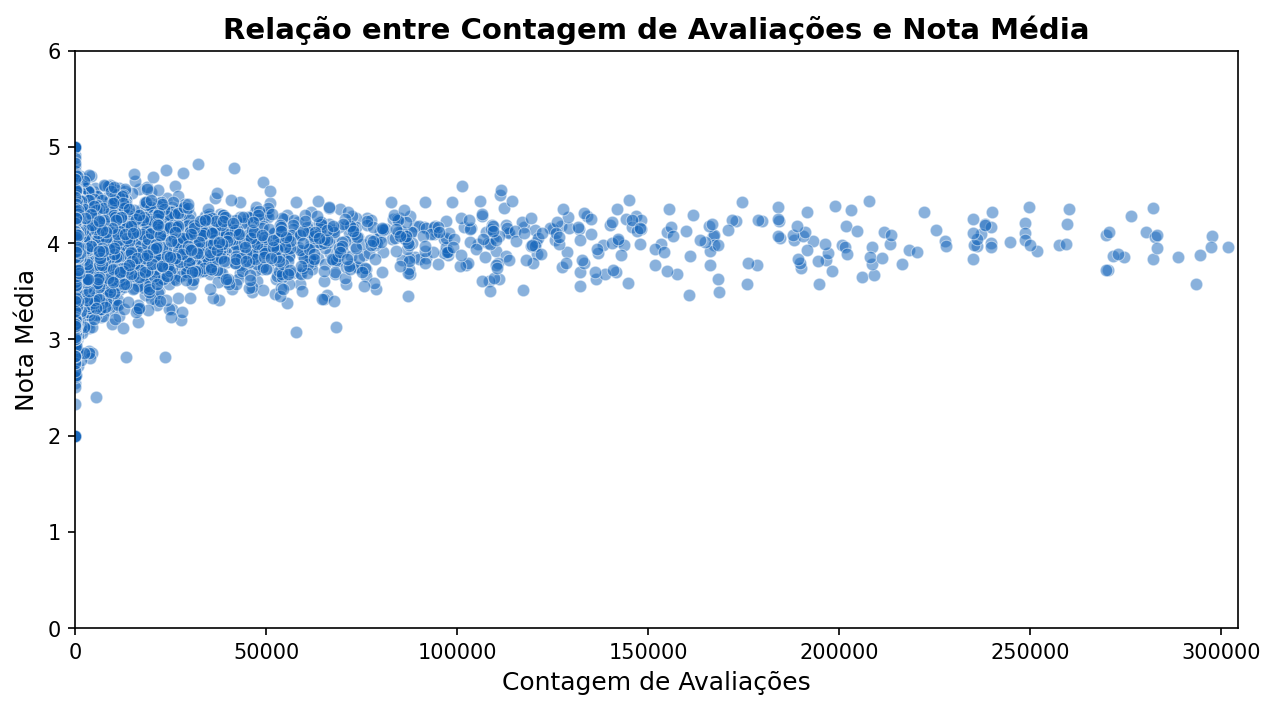

In [23]:
plt.figure(figsize=(10, 5), dpi=150)

sns.scatterplot(
    data=df_books,
    x='ratings_count',
    y='average_rating',
    alpha=0.5,
    color='#1465bb'
)
plt.title('Relação entre Contagem de Avaliações e Nota Média', fontsize=14, fontweight='bold')
plt.xlabel('Contagem de Avaliações', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)

plt.xlim(0, df_books['ratings_count'].quantile(0.99))
plt.ylim(0, 6)


In [24]:
# Verificando a distribuição dos livros com pouquíssimos votos

display(tb.estilizar_tabela(
    df=df_books[df_books['ratings_count'] <= 10]['ratings_count']
        .value_counts()
        .sort_index()
        .to_frame(name='Contagem'),
    caption="Quantidade de livros por número de votos (de 0 a 10):"
))

# Verificando especificamente quem tem apenas 1 voto
apenas_um = (df_books['ratings_count'] == 1).sum()
print(f"\nLivros que possuem exatamente 1 voto: {apenas_um}")

,Contagem
ratings_count,
1,67
2,65
3,76
4,63
5,52
6,53
7,54
8,54
9,55



Livros que possuem exatamente 1 voto: 67


In [25]:
print(f"Total de livros com pouquíssimos votos: {
    df_books[df_books['ratings_count'] <= 10]['ratings_count']
        .values
        .sum()
}")

Total de livros com pouquíssimos votos: 3100


In [26]:
media = df_books[df_books['ratings_count'] <= 10]['average_rating'].mean()

print(f"Média das notas dos livros com pouquíssimos votos (<= 10): {media:.2f}")

Média das notas dos livros com pouquíssimos votos (<= 10): 3.88


In [27]:
media = df_books[df_books['ratings_count'] == 1]['average_rating'].mean()

print(f"Média das notas dos livros com apenas 1 voto: {media:.2f}")

Média das notas dos livros com apenas 1 voto: 3.78


### Categorica VS Categorica

In [28]:
caminho = '../data/processed/books/goodreads_books_exploded.parquet'
df_exploded = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (94530, 12)


In [29]:
# Criar a Tabela de Contingência 

top_genres = df_exploded['genres'].value_counts().head(10).index
top_languages = df_exploded['language_code'].value_counts().head(10).index

tabela_contingencia = pd.crosstab(df_exploded['language_code'], df_exploded['genres'])

display(tb.estilizar_tabela(
    df=tabela_contingencia.loc[
        top_languages,
        top_genres
    ],
    caption='Tabela de Contingência (Valores Absolutos): language_code vs genres'
))

genres,Fiction,Classics,Nonfiction,Literature,Fantasy,Novels,"Historical,Historical Fiction",Audiobook,Mystery,History
language_code,,,,,,,,,,
eng,5512,2739,2426,2351,1959,2027,1467,1348,1319,1297
en-US,771,308,504,250,334,241,168,166,175,216
spa,170,78,26,67,75,89,52,44,39,11
en-GB,105,52,80,45,37,45,32,19,18,39
fre,117,59,12,62,42,63,23,20,23,6
ger,79,35,13,36,23,46,18,21,16,6
jpn,39,0,0,0,36,0,10,0,3,0
zho,14,5,0,2,13,3,1,4,0,0
mul,8,15,4,12,2,1,1,1,0,6


In [31]:
# Executando o Teste do Qui-Quadrado
chi2, p, dof, expected = mt.testar_dependencia_categorica(tabela_contingencia)


Resultados do Teste Estatístico
Estatística Qui-Quadrado: 49637.0783
Graus de Liberdade: 20424
p-valor: 0.0000e+00

Conclusão do Teste
Como o p-valor (0.0000e+00) < 0.05, REJEITAMOS a hipótese nula ($H_0$).
Conclusão: Existe uma associação estatisticamente significativa entre as duas variáveis!


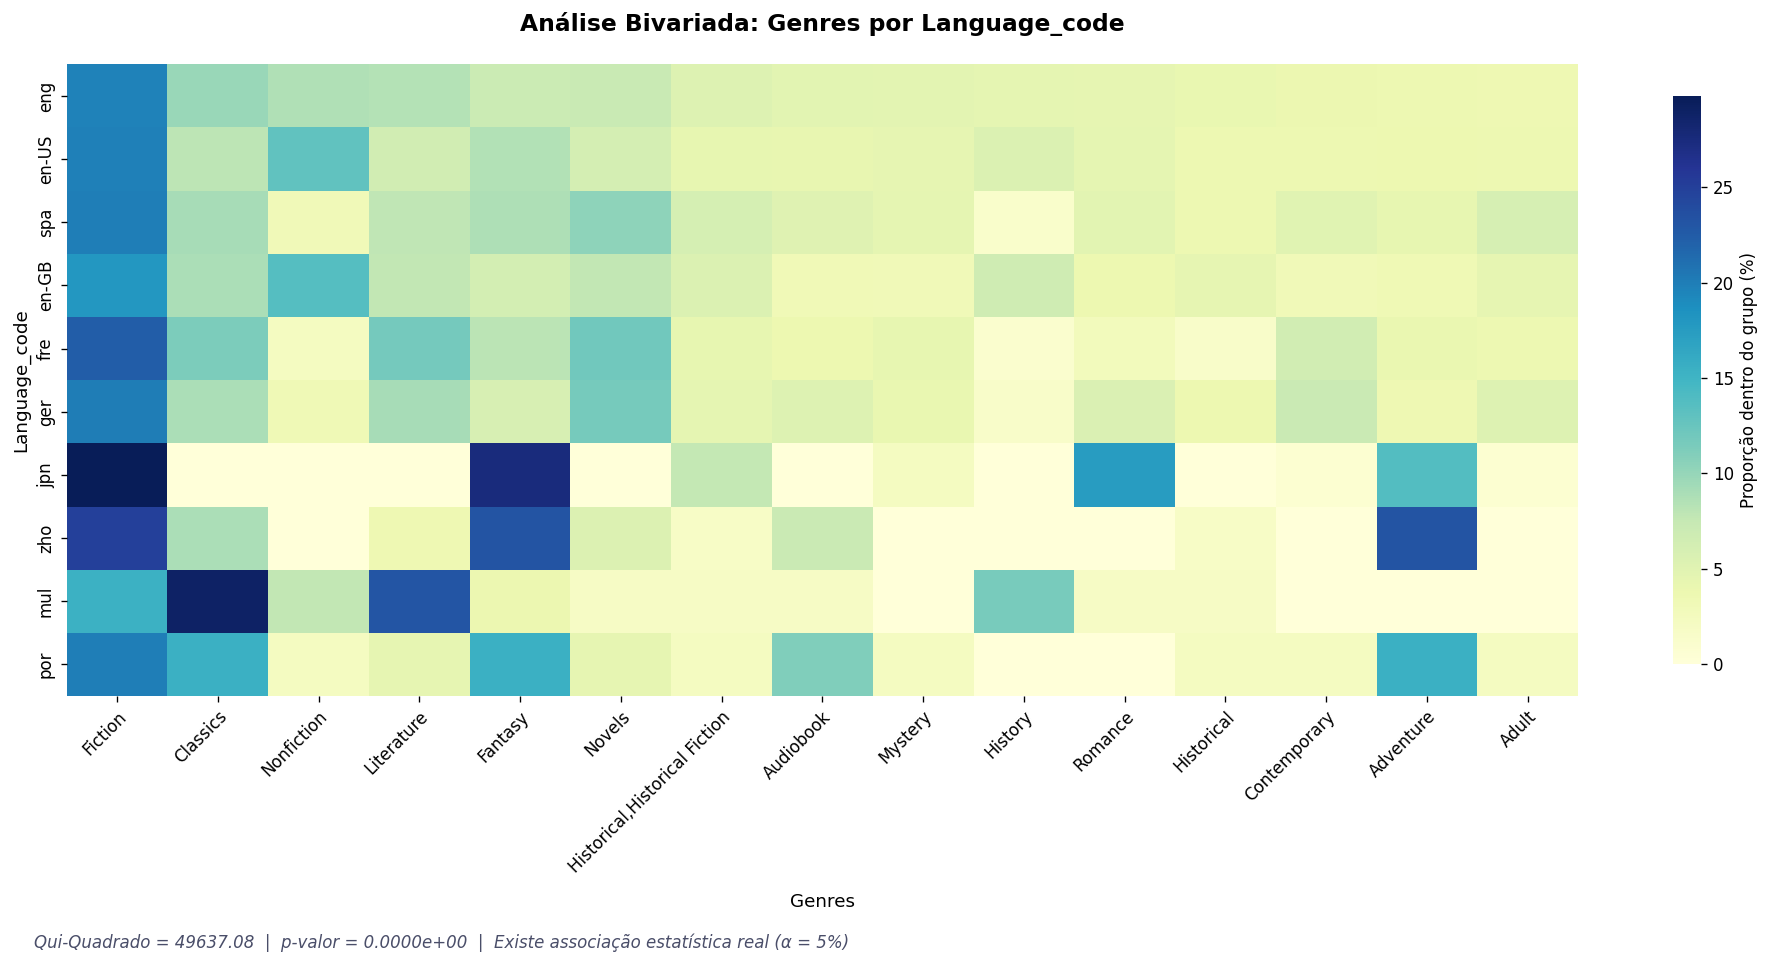

In [41]:
graf.grafico_dependencia_categorica_top_10(
    tabela_absoluta=tabela_contingencia,
    chi2=chi2,
    p_valor=p
)

### Observações Identificadas:

- Teste de Integridade Física (*Sanity Check*)

  - Antes de analisar distribuições, precisamos garantir que as variáveis numéricas respeitam os limites da realidade. Valores de páginas, quantidade de avaliações e notas não podem ser negativos. O objetivo aqui não é encontrar "livros ruins", mas detectar **corrompimento de dados na origem** — registros onde o próprio sistema de coleta falhou e gerou valores fisicamente impossíveis.

- Análise de Outliers Orgânicos

  - Com a base fisicamente íntegra, investigamos pontos fora da curva no **comportamento de engajamento da plataforma**. Diferente das anomalias físicas, outliers orgânicos são valores reais, mas estatisticamente extremos — eles existem porque o mundo é assim, não porque houve um erro.

  - Para identificá-los, analisamos visualmente as correlações entre as principais features numéricas por meio de *scatterplots*, técnica que permite enxergar tanto a tendência geral de uma relação quanto os pontos que fogem dela.

- Distribuição de Engajamento Mínimo

  - Após confirmar a ausência de erros físicos e compreender a natureza dos outliers orgânicos, foi realizado um terceiro diagnóstico: a análise do **limite inferior de engajamento estatístico**. A questão central aqui não é se o dado é real, mas se ele é *representativo o suficiente* para sustentar uma análise comparativa.

  - A análise de integridade revelou que não há registros com zero avaliações no dataset processado. Identificamos **67 obras com apenas 1 voto** (média de $3.78$) e **593 com menos de 10 votos** (média de $3.88$).

### Decisão e Tratamento:
  - O teste vetorial confirmou a ausência de valores negativos nas colunas numéricas, atestando a **integridade basal da extração**. O dataset passou por este crivo sem nenhuma violação lógica de domínio.

  -  Os pontos extremos identificados nos gráficos não representam erros sistêmicos, mas sim o fenômeno de **Cauda Longa literária** (*Long Tail*) — a coexistência de obras de altíssimo nicho com poucas resenhas e best-sellers globais com centenas de milhares de avaliações. Este é um comportamento esperado e genuíno de plataformas de conteúdo em larga escala. **Estes registros serão mantidos, pois refletem a realidade da plataforma.**
  
---

## Resumo Final Para Limpeza e Preparação

* **Estado Inicial:** O dataset bruto iniciou o processo com 12 colunas e 11.127 linhas.
* **Redução de Dimensionalidade:** A coluna `isbn13` será removida por ser estruturalmente redundante, mantendo-se apenas o identificador `isbn` principal.
* **Uniformização de Colunas** A coluna `Title` será editada para `title` para padronizala com os demais datasets. O mesmo ocorrerá com a coluna `Book Id` que se tornará `book_id`.
* **Tratamento de Nulos e Anomalias Numéricas:**
  * Os registros com valores ausentes na coluna `genres` serão descartados.
  * Obras com inconsistência de engajamento (notas `0.00` ou `ratings_count` zerado) serão removidas para não distorcer as médias estatísticas do projeto.
  * *Impacto do corte:* Apenas 162 linhas removidas (1,45% de perda, volume estatisticamente irrelevante).
* **Integridade Física Confirmada:** O teste vetorial sobre todas as colunas numéricas confirmou a ausência de valores negativos, validando que o pipeline de extração não gerou corrompimento de dados na origem.
* **Outliers Orgânicos Mantidos:** Os pontos extremos de engajamento identificados nos scatterplots (como best-sellers globais) refletem a realidade da plataforma e o fenômeno de Cauda Longa literária. Nenhuma remoção foi aplicada sobre eles.
* **Engajamento Mínimo:** 593 obras com menos de 10 avaliações foram sinalizadas como `"Baixa Relevância Estatística"`. Esses registros serão preservados no dataset exploratório, mas um *threshold* de corte será aplicado nas etapas de análise correlacional para garantir que o `average_rating` represente uma opinião coletiva e não individual.
* **Engenharia de Features (Refatoração):** A coluna de texto bruto `genres` será processada, fatiada e "explodida" em formato de lista, atomizando os dados para suportar a arquitetura de banco de dados relacional.
* **Estado Final Esperado (Dado Ouro):** O dataset purificado resultará em um DataFrame final e íntegro de **10.965 linhas**, pronto para ser injetado nas tabelas do banco de dados SQLite (`tropes_literarios.db`).